## Data Analysis FIFA

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('fifa_eda_stats.csv')
df.shape

(18207, 57)

In [7]:
df.head(10)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,€110.5M,€565K,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,€77M,€405K,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,€118.5M,€290K,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,Spain,91,93,Manchester United,€72M,€260K,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,€102M,€355K,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
5,183277,E. Hazard,27,Belgium,91,91,Chelsea,€93M,€340K,Right,...,91.0,34.0,27.0,22.0,11.0,12.0,6.0,8.0,8.0,€172.1M
6,177003,L. Modrić,32,Croatia,91,91,Real Madrid,€67M,€420K,Right,...,84.0,60.0,76.0,73.0,13.0,9.0,7.0,14.0,9.0,€137.4M
7,176580,L. Suárez,31,Uruguay,91,91,FC Barcelona,€80M,€455K,Right,...,85.0,62.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0,€164M
8,155862,Sergio Ramos,32,Spain,91,91,Real Madrid,€51M,€380K,Right,...,82.0,87.0,92.0,91.0,11.0,8.0,9.0,7.0,11.0,€104.6M
9,200389,J. Oblak,25,Slovenia,90,93,Atlético Madrid,€68M,€94K,Right,...,70.0,27.0,12.0,18.0,86.0,92.0,78.0,88.0,89.0,€144.5M


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     18207 non-null  object 
 8   Wage                      18207 non-null  object 
 9   Preferred Foot            18159 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Weak Foot                 18159 non-null  float64
 12  Skill Moves               18159 non-null  float64
 13  Work Rate                 18159 non-null  object 
 14  Body T

In [11]:
# 2. Handle Missing Values
# Drop columns that are mostly empty
df.drop(columns=['Loaned From'], inplace=True)

In [13]:
# Fill missing numerical statistics with the median
num_cols = df.select_dtypes(include=['float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [15]:
# Fill missing categorical data with 'Unknown'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [19]:
# 3. Clean Currency columns (Value, Wage, Release Clause)
# Removes the '€' symbol and multiplies 'M' (Millions) by 1,000,000 and 'K' (Thousands) by 1,000
def clean_currency(x):
    if pd.isna(x) or x == 'Unknown': return 0
    x = str(x).replace('€', '')
    if 'M' in x: return float(x.replace('M', '')) * 1000000
    elif 'K' in x: return float(x.replace('K', '')) * 1000
    return float(x)

for col in ['Value', 'Wage', 'Release Clause']:
    df[col] = df[col].apply(clean_currency)

# 4. Clean Height and Weight
# Convert Height from feet'inches to total inches
def clean_height(x):
    if pd.isna(x) or x == 'Unknown': return np.nan
    try:
        feet, inches = str(x).split("'")
        return int(feet) * 12 + int(inches)
    except:
        return np.nan

df['Height'] = df['Height'].apply(clean_height)

# Remove 'lbs' from Weight and convert to numerical float
df['Weight'] = df['Weight'].astype(str).str.replace('lbs', '').replace('Unknown', np.nan).astype(float)

# 5. Export for SQL / Power BI
df.to_csv('fifa_cleaned_data.csv', index=False)

In [21]:
import pandas as pd
import unicodedata

# 1. Define a function to normalize text (remove accents and special characters)
def normalize_text(text):
    if pd.isna(text) or text == 'Unknown':
        return text
    
    # unicodedata.normalize('NFD', text) separates the base character from its accent.
    # .encode('ascii', 'ignore') drops the accent characters.
    # .decode('utf-8') turns it back into a normal Python string.
    return unicodedata.normalize('NFD', str(text)).encode('ascii', 'ignore').decode('utf-8')

# 2. Apply the function to the Club column
df['Club'] = df['Club'].apply(normalize_text)

# (Optional but recommended) Apply to Player Names too!
df['Name'] = df['Name'].apply(normalize_text)

# Example output:
# 'Atlético Madrid'       -> 'Atletico Madrid'
# 'FC Bayern München'     -> 'FC Bayern Munchen'
# 'Medipol Başakşehir FK' -> 'Medipol Basaksehir FK'

In [23]:
df.head(10)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,565000.0,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226500000.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,405000.0,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127100000.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,290000.0,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228100000.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000000.0,260000.0,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138600000.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,355000.0,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196400000.0
5,183277,E. Hazard,27,Belgium,91,91,Chelsea,93000000.0,340000.0,Right,...,91.0,34.0,27.0,22.0,11.0,12.0,6.0,8.0,8.0,172100000.0
6,177003,L. Modric,32,Croatia,91,91,Real Madrid,67000000.0,420000.0,Right,...,84.0,60.0,76.0,73.0,13.0,9.0,7.0,14.0,9.0,137400000.0
7,176580,L. Suarez,31,Uruguay,91,91,FC Barcelona,80000000.0,455000.0,Right,...,85.0,62.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0,164000000.0
8,155862,Sergio Ramos,32,Spain,91,91,Real Madrid,51000000.0,380000.0,Right,...,82.0,87.0,92.0,91.0,11.0,8.0,9.0,7.0,11.0,104600000.0
9,200389,J. Oblak,25,Slovenia,90,93,Atletico Madrid,68000000.0,94000.0,Right,...,70.0,27.0,12.0,18.0,86.0,92.0,78.0,88.0,89.0,144500000.0


In [35]:
df['Height'].isnull().sum()

18207

In [37]:
# 2. Extract strictly the Year from 'Contract Valid Until'
# This looks for exactly 4 digits in a row (e.g. converting 'Jul 1, 2011' into '2011')
df['Contract Valid Until'] = df['Contract Valid Until'].astype(str).str.extract(r'(\d{4})')[0]

# After this, you can safely apply your missing-value fillers!
# df[num_cols].fillna(...)
# df[cat_cols].fillna(...)

In [41]:
df.isnull().sum()

ID                              0
Name                            0
Age                             0
Nationality                     0
Overall                         0
Potential                       0
Club                            0
Value                           0
Wage                            0
Preferred Foot                  0
International Reputation        0
Weak Foot                       0
Skill Moves                     0
Work Rate                       0
Body Type                       0
Position                        0
Jersey Number                   0
Joined                          0
Contract Valid Until          289
Height                      18207
Weight                         48
Crossing                        0
Finishing                       0
HeadingAccuracy                 0
ShortPassing                    0
Volleys                         0
Dribbling                       0
Curve                           0
FKAccuracy                      0
LongPassing   

In [43]:
# Drop the 'Height' column
df.drop(columns=['Height'], inplace=True)

In [45]:
df.isnull().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                          0
Value                         0
Wage                          0
Preferred Foot                0
International Reputation      0
Weak Foot                     0
Skill Moves                   0
Work Rate                     0
Body Type                     0
Position                      0
Jersey Number                 0
Joined                        0
Contract Valid Until        289
Weight                       48
Crossing                      0
Finishing                     0
HeadingAccuracy               0
ShortPassing                  0
Volleys                       0
Dribbling                     0
Curve                         0
FKAccuracy                    0
LongPassing                   0
BallControl                   0
Acceleration                  0
SprintSp

In [47]:
df.dropna()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500000.0,565000.0,Left,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226500000.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000000.0,405000.0,Right,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127100000.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500000.0,290000.0,Right,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228100000.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000000.0,260000.0,Right,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138600000.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000000.0,355000.0,Right,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196400000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,60000.0,1000.0,Right,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,143000.0
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60000.0,1000.0,Right,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,113000.0
18204,241638,B. Worman,16,England,47,67,Cambridge United,60000.0,1000.0,Right,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,165000.0
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60000.0,1000.0,Right,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,143000.0


In [51]:
df.isnull().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                          0
Value                         0
Wage                          0
Preferred Foot                0
International Reputation      0
Weak Foot                     0
Skill Moves                   0
Work Rate                     0
Body Type                     0
Position                      0
Jersey Number                 0
Joined                        0
Contract Valid Until        289
Weight                       48
Crossing                      0
Finishing                     0
HeadingAccuracy               0
ShortPassing                  0
Volleys                       0
Dribbling                     0
Curve                         0
FKAccuracy                    0
LongPassing                   0
BallControl                   0
Acceleration                  0
SprintSp

In [57]:
df['Contract Valid Until'].head(100)

0     2021
1     2022
2     2022
3     2020
4     2023
      ... 
95    2021
96    2021
97    2022
98    2020
99    2021
Name: Contract Valid Until, Length: 100, dtype: object

In [59]:
# Save the updated dataset
df.to_csv('fifa_cleaned_data_v4.csv', index=False)

## Data Analysis - Univariate and Bivariate

In [66]:
# Load data and set style
df = pd.read_excel('fifa_cleaned_data_v4.xlsx')
sns.set_theme(style="whitegrid")

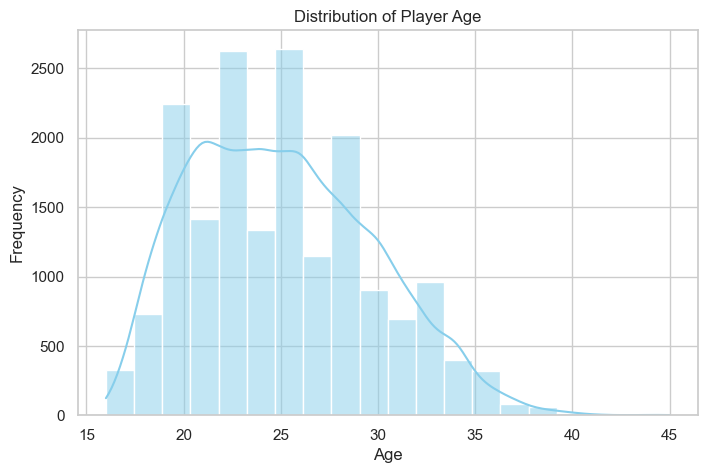

In [68]:
# 1. Distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Player Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('univariate_age.png', bbox_inches='tight')

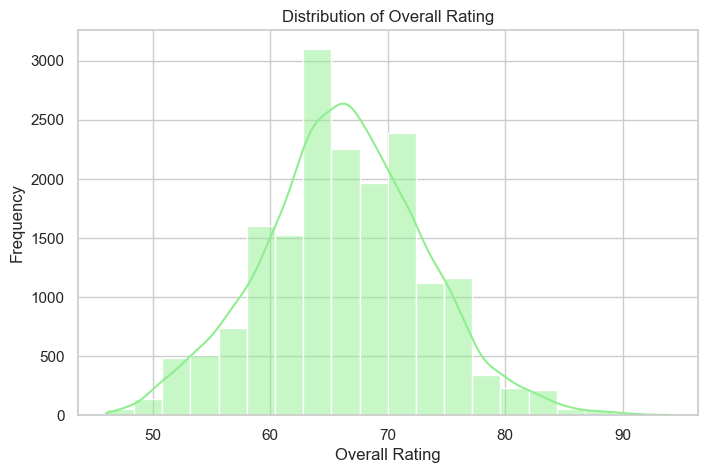

In [70]:
# 2. Distribution of Overall Rating
plt.figure(figsize=(8, 5))
sns.histplot(df['Overall'], bins=20, kde=True, color='lightgreen')
plt.title('Distribution of Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.savefig('univariate_overall.png', bbox_inches='tight')

C:\Users\krishna097\AppData\Local\Temp\ipykernel_6024\2155993017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_nations.index, x=top_nations.values, palette='viridis')


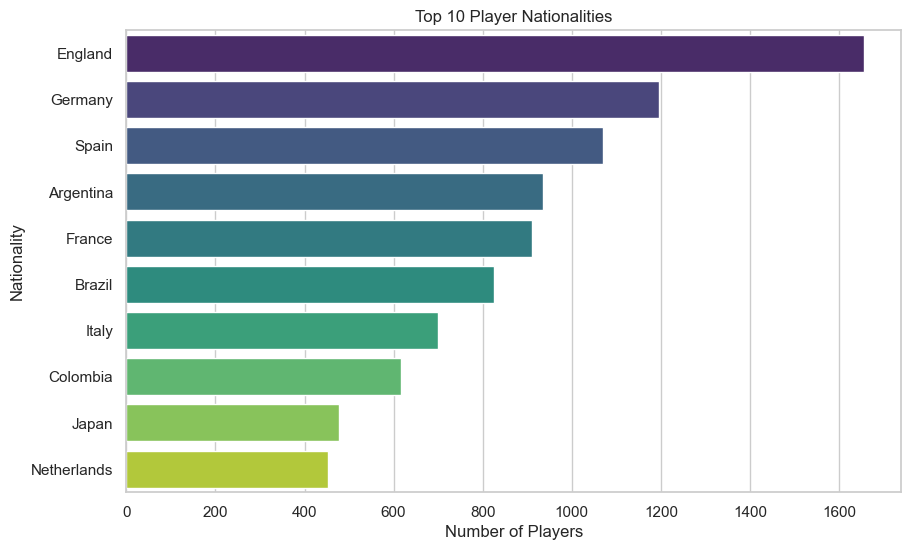

In [72]:
# 3. Top 10 Nationalities Bar Chart
plt.figure(figsize=(10, 6))
top_nations = df['Nationality'].value_counts().head(10)
sns.barplot(y=top_nations.index, x=top_nations.values, palette='viridis')
plt.title('Top 10 Player Nationalities')
plt.xlabel('Number of Players')
plt.ylabel('Nationality')
plt.savefig('univariate_nationality.png', bbox_inches='tight')

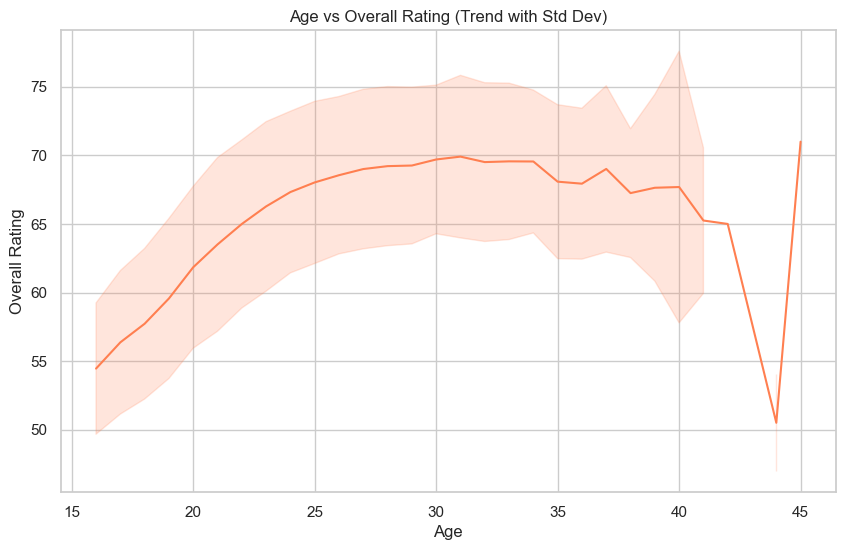

In [74]:
# 4. Age vs Overall Rating
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Age', y='Overall', errorbar='sd', color='coral')
plt.title('Age vs Overall Rating (Trend with Std Dev)')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.savefig('bivariate_age_overall.png', bbox_inches='tight')

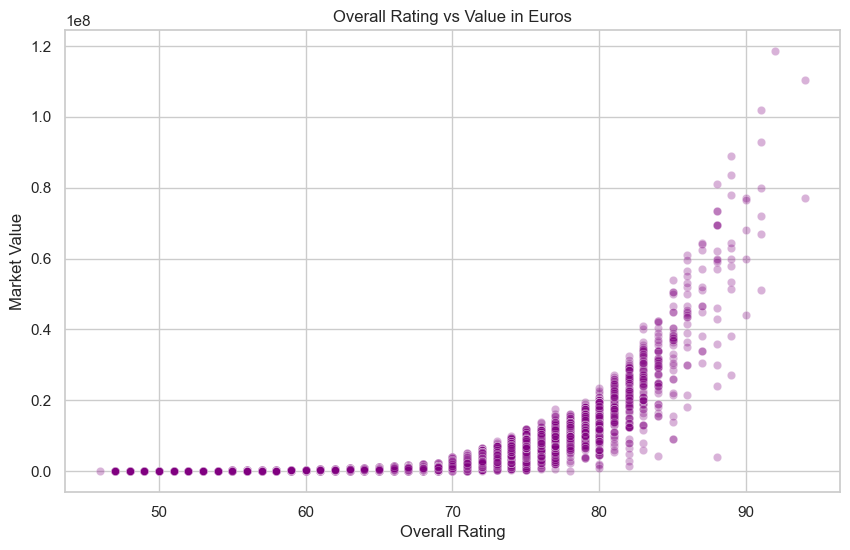

In [76]:
# 5. Overall Rating vs Value
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Overall', y='Value', alpha=0.3, color='purple')
plt.title('Overall Rating vs Value in Euros')
plt.xlabel('Overall Rating')
plt.ylabel('Market Value')
plt.savefig('bivariate_overall_value.png', bbox_inches='tight')

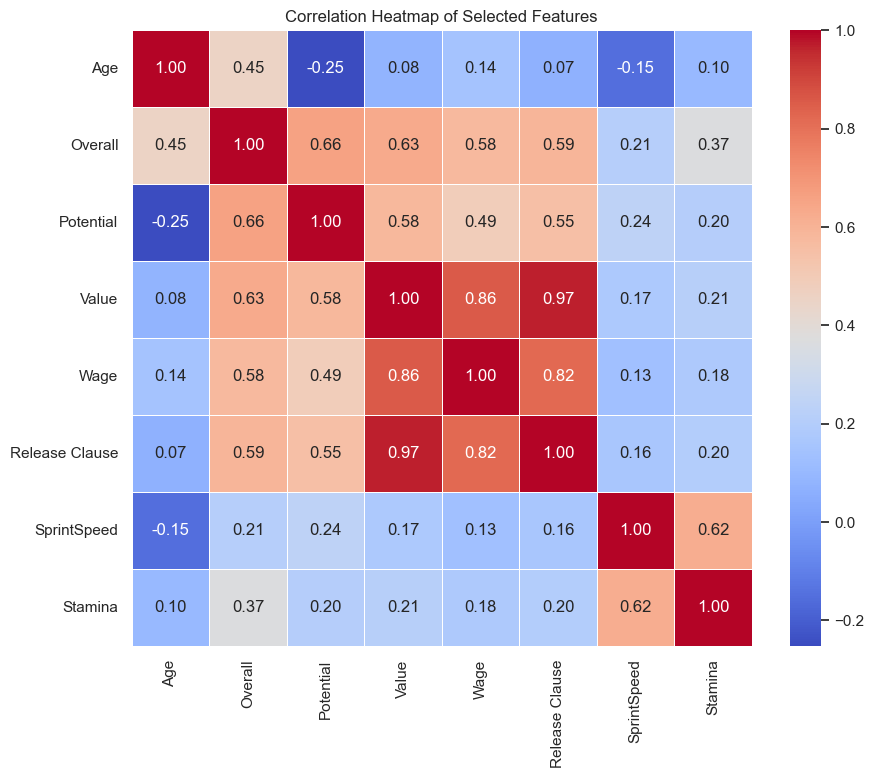

In [78]:
# 6. Correlation Heatmap
plt.figure(figsize=(10, 8))
selected_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Release Clause', 'SprintSpeed', 'Stamina']
corr = df[selected_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Features')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')